# Joins

In [2]:
import polars as pl

## Introducción a los Conjuntos de Datos
- Los datos en el mundo real pueden estar distribuidos en múltiples tablas/conjuntos de datos.
- Un join combina dos tablas/`DataFrames` basándose en un criterio lógico.
- En esta sección, exploraremos datos de un servicio de streaming ficticio (al estilo de Netflix).
- Todos los archivos CSV se encuentran en el directorio `streaming_service`.

- El conjunto de datos `movies.csv` contiene información sobre las películas disponibles en el servicio.

In [3]:
pl.read_csv("streaming_service/movies.csv").head(2)

id,title,budget,release_date,revenue,runtime,status
i64,str,i64,str,i64,i64,str
1,"""#Horror""",1500000,"""2015-11-20""",null,90,"""Released"""
2,"""(500) Days of Summer""",7500000,"""2009-07-17""",60722734,95,"""Released"""


- El archivo `plans.csv` lista los planes de suscripción del servicio de streaming.

In [4]:
pl.read_csv("streaming_service/plans.csv")

id,name,price,resolution
i64,str,f64,str
1,"""Basic""",8.99,"""720p"""
2,"""Standard""",13.99,"""1080p"""
3,"""Premium""",19.99,"""4K"""
4,"""Deluxe""",999.99,"""4K with Caviar"""


- El archivo `users.csv` lista los suscriptores (nombre, correo electrónico y el ID de su plan de suscripción).

In [5]:
pl.read_csv("streaming_service/users.csv").head(2)

id,name,email,subscription_plan_id
i64,str,str,i64
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2
2,"""Marcus Carlson""","""marcus861@protonmail.com""",3


- El archivo `watch_history.csv` es una tabla de unión que conecta un ID de usuario con un ID de película.

In [7]:
pl.read_csv("streaming_service/watch_history.csv").head(2)

id,user_id,movie_id,watched_on
i64,i64,i64,str
1,913,410,"""2025-07-17"""
2,2007,3658,"""2024-10-12"""


- El archivo `support.csv` es un conjunto de datos con quejas recibidas por soporte al cliente.
- Algunos tickets están conectados a un usuario/suscriptor específico; otros no lo están.

In [8]:
pl.read_csv("streaming_service/support.csv").head()

ticket_id,user_id,complaint
i64,i64,str
1,2557,"""billing"""
2,4534,"""video quality"""
3,2994,"""video quality"""
4,null,"""movie selection"""
5,null,"""movie selection"""


### Lectura Adicional
- https://docs.pola.rs/user-guide/transformations/joins/#quick-reference-table
- https://docs.pola.rs/user-guide/transformations/joins/#equi-joins

## Inner Join (Unión Interna)

In [9]:
movies = pl.read_csv("streaming_service/movies.csv")
plans = pl.read_csv("streaming_service/plans.csv")
users = pl.read_csv("streaming_service/users.csv")
watch_history = pl.read_csv("streaming_service/watch_history.csv")
support = pl.read_csv("streaming_service/support.csv")

- Un `inner` join fusiona las filas que tienen un valor coincidente en ambos `DataFrames`.
- Los inner joins son ideales cuando se quiere encontrar la intersección o solapamiento entre dos conjuntos de datos (los valores en común).
- Polars unirá las filas basándose en que el mismo valor exista en una columna especificada en ambas tablas.

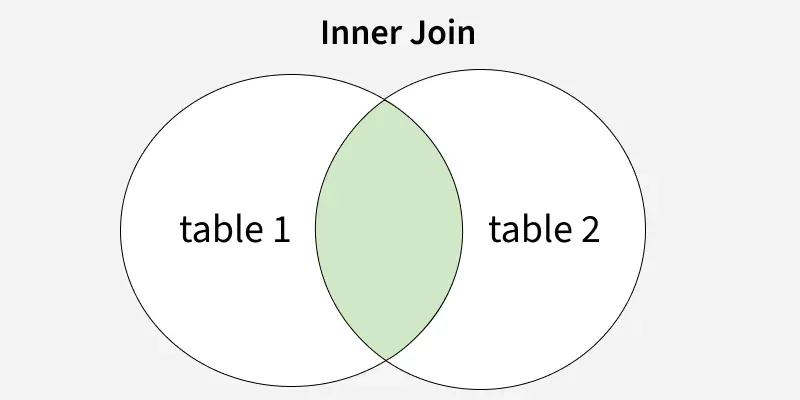

- Supongamos que quiero encontrar todas las películas que ha visto cada usuario.
- Una unión interna entre `users` y `watch_history` identifica a los usuarios cuyo ID aparece tanto en `users.id` como en `watch_history.user_id`.
- Polars excluye por defecto los valores nulos (faltantes) en las coincidencias. Un valor nulo no se considera igual a otro valor nulo.

In [10]:
users.head(3)

id,name,email,subscription_plan_id
i64,str,str,i64
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2
2,"""Marcus Carlson""","""marcus861@protonmail.com""",3
3,"""Robert Williams""","""robert107@outlook.com""",2


In [11]:
watch_history.head(3)

id,user_id,movie_id,watched_on
i64,i64,i64,str
1,913,410,"""2025-07-17"""
2,2007,3658,"""2024-10-12"""
3,840,1425,"""2027-04-24"""


### El Método `join`
- El método `join` fusiona dos `DataFrames`.
- El parámetro `other` establece el segundo `DataFrame`.
- El parámetro `how` declara la estrategia de unión.
- Polars agrega el sufijo `_right` a cualquier nombre de columna duplicado del `DataFrame` derecho.
- Polars excluye `watch_history.user_id` del resultado. El valor en esa columna es el mismo que `id`.

In [12]:
users.join(watch_history, how="inner", left_on="id", right_on="user_id")

id,name,email,subscription_plan_id,id_right,movie_id,watched_on
i64,str,str,i64,i64,i64,str
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2,1778,8575,"""2024-10-06"""
2,"""Marcus Carlson""","""marcus861@protonmail.com""",3,1881,568,"""2025-08-05"""
3,"""Robert Williams""","""robert107@outlook.com""",2,1671,2580,"""2024-06-26"""
5,"""Richard Parsons""","""richard615@yahoo.com""",5,51,5311,"""2026-09-27"""
6,"""Alexis Thompson""","""alexis467@protonmail.com""",2,1043,7010,"""2025-02-18"""
…,…,…,…,…,…,…
4978,"""Jennifer Leach""","""jennifer883@gmail.com""",3,614,7180,"""2024-03-12"""
4985,"""Pamela Marshall""","""pamela197@aol.com""",3,1877,3944,"""2027-02-27"""
4988,"""Michelle Scott""","""michelle866@pandas.edu""",1,1095,902,"""2025-09-25"""


- Identifiquemos los usuarios que vieron múltiples películas.
- El método `is_duplicated` devuelve True si una fila almacena un valor duplicado.

- El parámetro `suffix` agrega un sufijo personalizado a los nombres de columna duplicados del `DataFrame` derecho.
- La columna `id` de `watch_history` se convierte en `id_from_watch_history`.
- La columna `id` de `users` no se ve afectada y permanece como `id`.

In [13]:
users.join(
    watch_history,
    how="inner",
    left_on="id",
    right_on="user_id",
    suffix="_from_watch_history",
).filter(pl.col("id").is_duplicated())

id,name,email,subscription_plan_id,id_from_watch_history,movie_id,watched_on
i64,str,str,i64,i64,i64,str
22,"""Jeffrey Munoz""","""jeffrey682@outlook.com""",3,280,6694,"""2026-07-11"""
22,"""Jeffrey Munoz""","""jeffrey682@outlook.com""",3,329,4635,"""2025-09-03"""
22,"""Jeffrey Munoz""","""jeffrey682@outlook.com""",3,1110,722,"""2024-01-26"""
73,"""Jeffrey Roberts""","""jeffrey63@aol.com""",3,1314,7768,"""2024-09-27"""
73,"""Jeffrey Roberts""","""jeffrey63@aol.com""",3,1512,1880,"""2027-10-01"""
…,…,…,…,…,…,…
4958,"""Haley Turner""","""haley535@polars.edu""",3,900,6500,"""2025-10-30"""
4970,"""Maria Allen""","""maria14@yahoo.com""",1,668,2354,"""2025-10-02"""
4970,"""Maria Allen""","""maria14@yahoo.com""",1,1571,1344,"""2025-07-28"""


- En los inner joins, Polars excluye la columna de unión coincidente de la tabla derecha (`user_id` de `watch_history`).
- Los valores de la columna `watch_history.user_id` coincidirían con el valor de `users.id`.
- Pasa al parámetro `coalesce` el argumento `False` para incluir las columnas coincidentes.

In [14]:
users.join(
    watch_history,
    how="inner",
    left_on="id",
    right_on="user_id",
    suffix="_from_watch_history",
    coalesce=False,
)

id,name,email,subscription_plan_id,id_from_watch_history,user_id,movie_id,watched_on
i64,str,str,i64,i64,i64,i64,str
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2,1778,1,8575,"""2024-10-06"""
2,"""Marcus Carlson""","""marcus861@protonmail.com""",3,1881,2,568,"""2025-08-05"""
3,"""Robert Williams""","""robert107@outlook.com""",2,1671,3,2580,"""2024-06-26"""
5,"""Richard Parsons""","""richard615@yahoo.com""",5,51,5,5311,"""2026-09-27"""
6,"""Alexis Thompson""","""alexis467@protonmail.com""",2,1043,6,7010,"""2025-02-18"""
…,…,…,…,…,…,…,…
4978,"""Jennifer Leach""","""jennifer883@gmail.com""",3,614,4978,7180,"""2024-03-12"""
4985,"""Pamela Marshall""","""pamela197@aol.com""",3,1877,4985,3944,"""2027-02-27"""
4988,"""Michelle Scott""","""michelle866@pandas.edu""",1,1095,4988,902,"""2025-09-25"""


### Lectura Adicional
- https://docs.pola.rs/user-guide/transformations/joins/#inner-join
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join.html

## El Parámetro `on`
- El parámetro `on` puede designar la columna de unión _si_ el nombre de la columna es idéntico en ambas tablas.

In [15]:
movies = pl.read_csv("streaming_service/movies.csv")
plans = pl.read_csv("streaming_service/plans.csv")
users = pl.read_csv("streaming_service/users.csv").rename({"id": "user_id"}) # Importante!
watch_history = pl.read_csv("streaming_service/watch_history.csv")
support = pl.read_csv("streaming_service/support.csv")

In [ ]:
users.head(1)

user_id,name,email,subscription_plan_id
i64,str,str,i64
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2


In [ ]:
watch_history.head(1)

id,user_id,movie_id,watched_on
i64,i64,i64,str
1,913,410,"""2025-07-17"""


- Ejecutemos el inner join de la lección anterior.
- Los parámetros `left_on` y `right_on` siguen siendo válidos...

In [12]:
users.join(watch_history, how="inner", left_on="user_id", right_on="user_id")

user_id,name,email,subscription_plan_id,id,movie_id,watched_on
i64,str,str,i64,i64,i64,str
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2,1778,8575,"""2024-10-06"""
2,"""Marcus Carlson""","""marcus861@protonmail.com""",3,1881,568,"""2025-08-05"""
3,"""Robert Williams""","""robert107@outlook.com""",2,1671,2580,"""2024-06-26"""
5,"""Richard Parsons""","""richard615@yahoo.com""",5,51,5311,"""2026-09-27"""
6,"""Alexis Thompson""","""alexis467@protonmail.com""",2,1043,7010,"""2025-02-18"""
…,…,…,…,…,…,…
4978,"""Jennifer Leach""","""jennifer883@gmail.com""",3,614,7180,"""2024-03-12"""
4985,"""Pamela Marshall""","""pamela197@aol.com""",3,1877,3944,"""2027-02-27"""
4988,"""Michelle Scott""","""michelle866@pandas.edu""",1,1095,902,"""2025-09-25"""


- ...pero el parámetro `on` es más limpio.

In [16]:
users.join(watch_history, how="inner", on="user_id")

user_id,name,email,subscription_plan_id,id,movie_id,watched_on
i64,str,str,i64,i64,i64,str
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2,1778,8575,"""2024-10-06"""
2,"""Marcus Carlson""","""marcus861@protonmail.com""",3,1881,568,"""2025-08-05"""
3,"""Robert Williams""","""robert107@outlook.com""",2,1671,2580,"""2024-06-26"""
5,"""Richard Parsons""","""richard615@yahoo.com""",5,51,5311,"""2026-09-27"""
6,"""Alexis Thompson""","""alexis467@protonmail.com""",2,1043,7010,"""2025-02-18"""
…,…,…,…,…,…,…
4978,"""Jennifer Leach""","""jennifer883@gmail.com""",3,614,7180,"""2024-03-12"""
4985,"""Pamela Marshall""","""pamela197@aol.com""",3,1877,3944,"""2027-02-27"""
4988,"""Michelle Scott""","""michelle866@pandas.edu""",1,1095,902,"""2025-09-25"""


### Lectura Adicional
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join.html

## Full Outer Joins (Unión Completa Externa)
- Al igual que un inner join, un full join unirá filas basándose en un valor compartido en las columnas especificadas.
- A diferencia de un inner join, un full join conservará una fila aunque no tenga coincidencia en el otro `DataFrame`.
- Polars rellenará los valores restantes de la fila con `null` si no hay coincidencia con el otro `DataFrame`.

In [17]:
movies = pl.read_csv("streaming_service/movies.csv")
plans = pl.read_csv("streaming_service/plans.csv")
users = pl.read_csv("streaming_service/users.csv")
watch_history = pl.read_csv("streaming_service/watch_history.csv")
support = pl.read_csv("streaming_service/support.csv")

In [19]:
plans

id,name,price,resolution
i64,str,f64,str
1,"""Basic""",8.99,"""720p"""
2,"""Standard""",13.99,"""1080p"""
3,"""Premium""",19.99,"""4K"""
4,"""Deluxe""",999.99,"""4K with Caviar"""


In [20]:
users.head(2)

id,name,email,subscription_plan_id
i64,str,str,i64
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2
2,"""Marcus Carlson""","""marcus861@protonmail.com""",3


- Un registro huérfano es una entrada que no tiene un registro coincidente en la otra tabla.
- Una unión completa es ideal para identificar registros huérfanos (usuarios cuyo ID de plan no es válido, planes sin usuarios).
- Richard Parsons tiene un `subscription_plan_id` (5) que no existe en el `DataFrame` de `plans`.
- Las entradas de fila para Richard Parsons son `null`. No hay valores para extraer de una fila coincidente en el `DataFrame` de `plans`.
- El plan Deluxe y su ID (4) no tienen ningún usuario suscrito.
- La fila del plan Deluxe tiene valores `null` para el `id`, `name`, `email` y `subscription_plan_id` del usuario.

In [18]:
users.join(
    plans,
    how="full",
    left_on="subscription_plan_id",
    right_on="id",
    suffix="_from_plans",
)

id,name,email,subscription_plan_id,id_from_plans,name_from_plans,price,resolution
i64,str,str,i64,i64,str,f64,str
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2,2,"""Standard""",13.99,"""1080p"""
2,"""Marcus Carlson""","""marcus861@protonmail.com""",3,3,"""Premium""",19.99,"""4K"""
3,"""Robert Williams""","""robert107@outlook.com""",2,2,"""Standard""",13.99,"""1080p"""
4,"""Molly Torres""","""molly701@polars.edu""",1,1,"""Basic""",8.99,"""720p"""
5,"""Richard Parsons""","""richard615@yahoo.com""",5,null,null,null,null
…,…,…,…,…,…,…,…
4997,"""Joshua Harrington""","""joshua522@polars.edu""",3,3,"""Premium""",19.99,"""4K"""
4998,"""Kenneth Sanchez""","""kenneth212@outlook.com""",2,2,"""Standard""",13.99,"""1080p"""
4999,"""Jasmine Hall""","""jasmine8@hotmail.com""",3,3,"""Premium""",19.99,"""4K"""


- Identifiquemos los usuarios que están suscritos a un plan de suscripción inexistente.

In [20]:
users.join(
    plans,
    how="full",
    left_on="subscription_plan_id",
    right_on="id",
    suffix="_from_plans",
).filter(pl.col("id_from_plans").is_null())

id,name,email,subscription_plan_id,id_from_plans,name_from_plans,price,resolution
i64,str,str,i64,i64,str,f64,str
5,"""Richard Parsons""","""richard615@yahoo.com""",5,null,null,null,null


- Identifiquemos los planes que no tienen usuarios suscritos.

In [21]:
users.join(
    plans,
    how="full",
    left_on="subscription_plan_id",
    right_on="id",
    suffix="_from_plans",
).filter(pl.col("id").is_null())

id,name,email,subscription_plan_id,id_from_plans,name_from_plans,price,resolution
i64,str,str,i64,i64,str,f64,str
null,null,null,null,4,"""Deluxe""",999.99,"""4K with Caviar"""


### Lectura Adicional
- https://docs.pola.rs/user-guide/transformations/joins/#full-join
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join.html

## Left y Right Joins (Uniones Izquierda y Derecha)
- Un left join conserva todos los registros de la tabla izquierda y fusiona las filas coincidentes (cuando sea posible) de la tabla derecha.
- Todas las filas de la tabla izquierda estarán presentes. Donde no haya coincidencia, Polars rellenará con `null` las columnas de la tabla derecha.

In [22]:
movies = pl.read_csv("streaming_service/movies.csv")
plans = pl.read_csv("streaming_service/plans.csv")
users = pl.read_csv("streaming_service/users.csv")
watch_history = pl.read_csv("streaming_service/watch_history.csv")
support = pl.read_csv("streaming_service/support.csv")

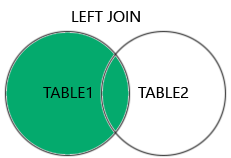

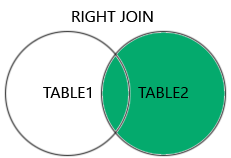

In [23]:
support.head(4)

ticket_id,user_id,complaint
i64,i64,str
1,2557,"""billing"""
2,4534,"""video quality"""
3,2994,"""video quality"""
4,null,"""movie selection"""


In [24]:
users.head(2)

id,name,email,subscription_plan_id
i64,str,str,i64
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2
2,"""Marcus Carlson""","""marcus861@protonmail.com""",3


- Los tres primeros tickets de soporte tienen un usuario asociado que podemos identificar por ID en la tabla `users`.
- El cuarto ticket no tiene `user_id`; los valores de la fila para `name`, `email` y `subscription_plan_id` serán null.

In [20]:
support.head(4)

ticket_id,user_id,complaint
i64,i64,str
1,2557,"""billing"""
2,4534,"""video quality"""
3,2994,"""video quality"""
4,null,"""movie selection"""


In [25]:
support.head(4).join(users, how="left", left_on="user_id", right_on="id")

ticket_id,user_id,complaint,name,email,subscription_plan_id
i64,i64,str,str,str,i64
1,2557,"""billing""","""Louis Rodriguez""","""louis10@hotmail.com""",2
2,4534,"""video quality""","""James Wilson""","""james788@hotmail.com""",2
3,2994,"""video quality""","""John Cole""","""john450@pandas.edu""",1
4,null,"""movie selection""",null,null,null


- Un right join sobre el `DataFrame` `users` logrará el mismo resultado.
- La tabla derecha (`support`) sigue siendo la tabla ancla/fuente de verdad. Todas sus filas se conservarán.
- Polars traerá las filas donde `users.id` coincida con `support.user_id`.
- El orden de las columnas será diferente.

In [27]:
users.join(support.head(4), how="right", left_on="id", right_on="user_id")

name,email,subscription_plan_id,ticket_id,user_id,complaint
str,str,i64,i64,i64,str
"""Louis Rodriguez""","""louis10@hotmail.com""",2,1,2557,"""billing"""
"""James Wilson""","""james788@hotmail.com""",2,2,4534,"""video quality"""
"""John Cole""","""john450@pandas.edu""",1,3,2994,"""video quality"""
null,null,null,4,null,"""movie selection"""


### Lectura Adicional
- https://docs.pola.rs/user-guide/transformations/joins/#left-join
- https://docs.pola.rs/user-guide/transformations/joins/#right-join
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join.html

## Semi Join
- Un semi join conserva solo las filas del `DataFrame` izquierdo que tienen una coincidencia en el `DataFrame` derecho.
- Sin embargo, Polars no concatena las columnas del `DataFrame` derecho al `DataFrame` resultante.
- Un semi join se parece más a una operación de filtro que a una unión.

In [28]:
movies = pl.read_csv("streaming_service/movies.csv")
plans = pl.read_csv("streaming_service/plans.csv")
users = pl.read_csv("streaming_service/users.csv")
watch_history = pl.read_csv("streaming_service/watch_history.csv")
support = pl.read_csv("streaming_service/support.csv")

In [ ]:
users.head(1)

id,name,email,subscription_plan_id
i64,str,str,i64
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2


In [ ]:
support.head(4)

ticket_id,user_id,complaint
i64,i64,str
1,2557,"""billing"""
2,4534,"""video quality"""
3,2994,"""video quality"""
4,null,"""movie selection"""


- Caso de negocio: Filtremos los usuarios que crearon al menos un ticket de soporte.
- Invoca `join` sobre `users` para que el `DataFrame` resultante tenga las columnas de la tabla `users`.

In [29]:
users.join(support, how="semi", left_on="id", right_on="user_id")

id,name,email,subscription_plan_id
i64,str,str,i64
32,"""Gregory Davis""","""gregory21@gmail.com""",3
48,"""Joseph Lawson""","""joseph390@pandas.edu""",3
61,"""Alexandra Luna""","""alexandra749@yahoo.com""",1
72,"""Jesse Elliott""","""jesse648@outlook.com""",3
198,"""James Becker MD""","""james920@hotmail.com""",3
…,…,…,…
4681,"""Andrew Anderson""","""andrew97@gmail.com""",3
4826,"""Craig Avila""","""craig667@hotmail.com""",3
4881,"""Kelly Mejia""","""kelly693@aol.com""",2


### Lectura Adicional
- https://docs.pola.rs/user-guide/getting-started/#joining-dataframes
- https://docs.pola.rs/user-guide/transformations/joins/#semi-join
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join.html

## Anti Join (Unión Anti)
- El anti join es lo opuesto al semi join.
- El anti join conserva las filas del `DataFrame` izquierdo que no tienen coincidencia en el `DataFrame` derecho.

In [30]:
movies = pl.read_csv("streaming_service/movies.csv")
plans = pl.read_csv("streaming_service/plans.csv")
users = pl.read_csv("streaming_service/users.csv")
watch_history = pl.read_csv("streaming_service/watch_history.csv")
support = pl.read_csv("streaming_service/support.csv")

In [ ]:
users.head(3)

id,name,email,subscription_plan_id
i64,str,str,i64
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2
2,"""Marcus Carlson""","""marcus861@protonmail.com""",3
3,"""Robert Williams""","""robert107@outlook.com""",2


In [ ]:
support.head(3)

ticket_id,user_id,complaint
i64,i64,str
1,2557,"""billing"""
2,4534,"""video quality"""
3,2994,"""video quality"""


- Caso de negocio: Identificar los usuarios que no presentaron un ticket/queja.
- Queremos encontrar las filas con un `id` en `users` (izquierda) que no tengan coincidencia en `support.user_id`.

In [31]:
users.join(support, how="anti", left_on="id", right_on="user_id")

id,name,email,subscription_plan_id
i64,str,str,i64
1,"""Alicia Palmer""","""alicia103@hotmail.com""",2
2,"""Marcus Carlson""","""marcus861@protonmail.com""",3
3,"""Robert Williams""","""robert107@outlook.com""",2
4,"""Molly Torres""","""molly701@polars.edu""",1
5,"""Richard Parsons""","""richard615@yahoo.com""",5
…,…,…,…
4995,"""Shawn Ayers""","""shawn651@hotmail.com""",3
4996,"""Sarah Bowers""","""sarah309@hotmail.com""",3
4998,"""Kenneth Sanchez""","""kenneth212@outlook.com""",2


### Lectura Adicional
- https://docs.pola.rs/user-guide/transformations/joins/#anti-join
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join.html

## Cross Joins (Unión Cruzada)
- Un cross join empareja cada fila del `DataFrame` izquierdo con cada fila del `DataFrame` derecho.
- Esta estrategia se llama producto cartesiano.
- La longitud del `DataFrame` resultante será igual al producto de las longitudes de ambos `DataFrames`.
- El parámetro `on` no es necesario porque cada fila izquierda se emparejará con cada fila derecha.

In [31]:
foods = pl.DataFrame(
    {
      "food": ["Hamburger", "Hotdog", "Chicken Fingers"]
     , "calories": [354, 151, 185]
     }
)

foods

food,calories
str,i64
"""Hamburger""",354
"""Hotdog""",151
"""Chicken Fingers""",185


In [32]:
condiments = pl.DataFrame({
    "condiment": ["Ketchup", "Mustard"]
    , "calories": [19, 3]
    })

condiments

condiment,calories
str,i64
"""Ketchup""",19
"""Mustard""",3


- Un cross join incluirá todas las columnas de ambos `DataFrames`.
- Polars agregará `_right` a las columnas duplicadas del `DataFrame` derecho.

In [33]:
foods.join(condiments, how="cross", suffix="_from_condiments")

food,calories,condiment,calories_from_condiments
str,i64,str,i64
"""Hamburger""",354,"""Ketchup""",19
"""Hamburger""",354,"""Mustard""",3
"""Hotdog""",151,"""Ketchup""",19
"""Hotdog""",151,"""Mustard""",3
"""Chicken Fingers""",185,"""Ketchup""",19
"""Chicken Fingers""",185,"""Mustard""",3


### Lectura Adicional
- https://docs.pola.rs/user-guide/transformations/joins/#cartesian-product
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join.html

## Unión por Múltiples Columnas
- Polars puede unir `DataFrames` basándose en valores coincidentes en múltiples columnas.
- Imaginemos que administramos una cadena de tiendas.
- Gestionamos el inventario de la tienda en un sistema y los productos en otro.
- El sistema de inventario almacena las unidades restantes de cada producto por tienda.

In [34]:
inventory = pl.read_csv("store/inventory.csv")
inventory

store_id,product_id,quantity
i64,i64,i64
1,101,5
1,102,2
1,103,6
2,103,7
2,104,3
3,201,1


- El sistema de precios almacena el precio de cada producto por tienda.

In [35]:
prices = pl.read_csv("store/prices.csv")
prices

store_id,product_id,price
i64,i64,i64
1,102,10
1,101,10
1,103,5
2,105,12
2,201,15
3,201,8


- Repaso: Un **inner join** fusiona las filas donde los valores existen y coinciden en _ambos_ `DataFrames`.
- Un inner join con múltiples columnas fusionará filas basándose en valores coincidentes tanto en `store_id` como en `product_id`.
- Si el `store_id` coincide pero el `product_id` no coincide, Polars no une las filas.
- Si el `product_id` coincide pero el `store_id` no coincide, Polars no une las filas.
- Pasa a los parámetros `on`/`left_on`/`right_on` una lista de nombres de columnas.

In [ ]:
# inventory.join(prices, how="inner", left_on=["store_id", "product_id"], right_on=["store_id", "product_id"])

In [36]:
inventory.join(prices, how="inner", on=["store_id", "product_id"])

store_id,product_id,quantity,price
i64,i64,i64,i64
1,102,2,10
1,101,5,10
1,103,6,5
3,201,1,8


- Repaso: Un **full join** trae todas las filas de ambos `DataFrames`.
- Polars unirá las filas donde `store_id` y `product_id` coincidan.
- Polars conservará las filas sin valores complementarios coincidentes...
- ...pero esas filas tendrán valores `null` en las otras columnas.

In [37]:
inventory.join(prices, how="full", on=["store_id", "product_id"], suffix="_from_prices")

store_id,product_id,quantity,store_id_from_prices,product_id_from_prices,price
i64,i64,i64,i64,i64,i64
1,102,2,1,102,10
1,101,5,1,101,10
1,103,6,1,103,5
null,null,null,2,105,12
null,null,null,2,201,15
3,201,1,3,201,8
2,103,7,null,null,null
2,104,3,null,null,null


- Repaso: Un **left join** conserva todas las filas de `inventory` y trae las filas coincidentes de `prices`.
- Polars rellenará con `null` la columna `price` si la combinación de `store_id` y `product_id` no existe en `prices`.
- Polars excluirá las filas de `prices` sin una combinación coincidente de `store_id` + `product_id`.

In [38]:
inventory.join(prices, how="left", on=["store_id", "product_id"])

store_id,product_id,quantity,price
i64,i64,i64,i64
1,101,5,10
1,102,2,10
1,103,6,5
2,103,7,null
2,104,3,null
3,201,1,8


- Repaso: Un **semi join** selecciona/filtra las filas de `inventory` donde `store_id` y `product_id` existen en `prices`.
- Un semi join no trae los datos correspondientes de `prices`.
- Los semi joins aíslan los `store_id` y `product_id`s que existen en ambas tablas.
- Por ejemplo, una fila con `store_id=1` y `product_id=101` existe en ambas tablas.

In [39]:
inventory.join(prices, how="semi", on=["store_id", "product_id"])

store_id,product_id,quantity
i64,i64,i64
1,101,5
1,102,2
1,103,6
3,201,1


- Repaso: Un **anti join** selecciona/filtra las filas de `inventory` donde `store_id` y `product_id` no existen en `prices`.
- Un anti join identifica qué combinaciones de `store_id` y `product_id` de `inventory` no existen en `prices`.
- Por ejemplo, una fila con `store_id=2` y `product_id=103` existe en `inventory` pero no existe en la tabla `prices`.

In [40]:
inventory.join(prices, how="anti", on=["store_id", "product_id"])

store_id,product_id,quantity
i64,i64,i64
2,103,7
2,104,3


### Lectura Adicional
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join.html

## El Parámetro `validate`

El parámetro `validate` en Polars es una herramienta de control de calidad. Sirve para asegurar que la relación entre las tablas (DataFrames) sea la que esperas (por ejemplo, que no haya duplicados inesperados en la tabla de referencia).

Las opciones son:

* `m:m`: (Muchos a muchos) Es la opción por defecto. No realiza validaciones.
* `1:1`: Valida que la clave de unión sea única en ambos DataFrames.
* `1:m`: Valida que la clave sea única en el DataFrame de la izquierda.
* `m:1`: Valida que la clave sea única en el DataFrame de la derecha.

Si la validación falla, Polars lanzará un error (ComputeError), lo que evita que proceses datos incorrectos o que el join genere una explosión de filas no deseada.

In [41]:
students = pl.read_csv("college/students.csv")
students.head(2)

student_id,name
i64,str
101,"""Emma"""
102,"""Noah"""


In [42]:
enrollments = pl.read_csv("college/enrollments.csv")
enrollments.head(2)

student_id,class_name
i64,str
101,"""Yoga"""
101,"""Boxing"""


In [37]:
# left : right
# 1 - join key will occur only once
# m - join key can occur multiple times ("many")
# m:m (many-to-many)
students.join(enrollments, how="inner", on="student_id", validate="m:m")

student_id,name,class_name
i64,str,str
101,"""Emma""","""Yoga"""
101,"""Emma""","""Boxing"""
102,"""Noah""","""Yoga"""
103,"""Olivia""","""Spin"""
103,"""Olivia""","""Boxing"""
103,"""Olivia""","""CrossFit"""


- La validación `1:m` (1 a muchos) verifica que la(s) clave(s) de unión sean únicas en el conjunto de datos izquierdo.
- Cada `student_id` debe existir solo una vez en el `DataFrame` `students` (esa es la parte del `1`).
- _Puede_ haber múltiples ocurrencias del mismo `student_id` en `enrollments` (esa es la parte del `m`).

In [43]:
# students (1) -> join key of student_id cannot repeat
# enrollments (m) -> join key of student_id can repeat
students.join(enrollments, how="inner", on="student_id", validate="1:m")

student_id,name,class_name
i64,str,str
101,"""Emma""","""Yoga"""
101,"""Emma""","""Boxing"""
102,"""Noah""","""Yoga"""
103,"""Olivia""","""Spin"""
103,"""Olivia""","""Boxing"""
103,"""Olivia""","""CrossFit"""


- Un parámetro `validate` establecido en `1:1` asegura que las claves de unión sean únicas en ambos `DataFrames` izquierdo y derecho.
- Cada valor en el `DataFrame` izquierdo puede coincidir como máximo una vez con un valor en el `DataFrame` derecho.
- Una validación `1:1` fallará aquí porque el mismo `student_id` se repite en el `DataFrame` `enrollments`.

In [44]:
# students (1) - join key of student_id must be unique
# enrollments (1) - join key of student_id must also be unique
# students.join(enrollments, how="inner", on="student_id", validate="1:1")

- La validación invertida `m:1` (muchos a 1) verifica que la(s) clave(s) de unión sean únicas en el conjunto de datos derecho.
- _Puede_ haber múltiples ocurrencias del mismo `student_id` en `enrollments` (esa es la parte del `m`).
- Cada `student_id` debe existir solo una vez en el `DataFrame` `students` (esa es la parte del `1`).
- El ejemplo es el mismo que el anterior pero los `DataFrames` izquierdo y derecho están invertidos.

In [46]:
# enrollments (m) - join key of student_id can repeat
# students (1) - join key of student_id must be unique
enrollments.join(students, how="inner", on="student_id", validate="m:1")

student_id,class_name,name
i64,str,str
101,"""Yoga""","""Emma"""
101,"""Boxing""","""Emma"""
102,"""Yoga""","""Noah"""
103,"""Spin""","""Olivia"""
103,"""Boxing""","""Olivia"""
103,"""CrossFit""","""Olivia"""


### Lectura Adicional
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join.html

## El Método `join_asof` I
- El método `join_asof` empareja valores por la coincidencia _más cercana_ en lugar de una coincidencia exacta.
- Esta técnica es particularmente útil al trabajar con datos de series temporales.
- El valor datetime de una fila puede no coincidir perfectamente con una entrada datetime en otra tabla.
- "as of" significa "hasta o antes de un momento dado". Ej.: "El sistema estaba funcionando a las 9am de esta mañana"
- El archivo `outages.csv` muestra las marcas de tiempo de incidencias en un sitio web.

In [47]:
outages = pl.read_csv("outages/outages.csv", try_parse_dates=True).sort("timestamp")
outages

timestamp,reported_issue
datetime[μs],str
2026-01-01 00:05:00,"""Slow load times"""
2026-01-01 00:25:00,"""Website down"""
2026-01-01 00:47:00,"""SSL handshake failed"""
2026-01-01 01:13:00,"""Unexpected redirect"""
2026-01-01 01:50:00,"""500 errors"""


- El archivo `uptime_checks.csv` muestra las marcas de tiempo de las verificaciones de disponibilidad.
- El sitio web realiza una verificación de disponibilidad cada 10 minutos.
- Un valor de "OK" indica que no hubo problemas en ese momento.

In [48]:
uptime_checks = pl.read_csv("outages/uptime_checks.csv", try_parse_dates=True).sort(
    "check_timestamp"
)
uptime_checks.head()

check_timestamp,status
datetime[μs],str
2026-01-01 00:00:00,"""OK"""
2026-01-01 00:10:00,"""Timeout"""
2026-01-01 00:20:00,"""Timeout"""
2026-01-01 00:30:00,"""OK"""
2026-01-01 00:40:00,"""OK"""


- Para usar `join_asof`, ordena ambos `DataFrames` usando la columna `on` (las columnas cuyos valores se usarán para la unión).
- Una búsqueda hacia atrás (backward) selecciona la última fila del `DataFrame` derecho cuya clave es menor o igual a la clave del izquierdo.
- La estrategia por defecto es `backward`.

In [49]:
outages.join_asof(uptime_checks, left_on="timestamp", right_on="check_timestamp")

# outages.join_asof(
#     uptime_checks, left_on="timestamp", right_on="check_timestamp", strategy="backward"
# )

timestamp,reported_issue,check_timestamp,status
datetime[μs],str,datetime[μs],str
2026-01-01 00:05:00,"""Slow load times""",2026-01-01 00:00:00,"""OK"""
2026-01-01 00:25:00,"""Website down""",2026-01-01 00:20:00,"""Timeout"""
2026-01-01 00:47:00,"""SSL handshake failed""",2026-01-01 00:40:00,"""OK"""
2026-01-01 01:13:00,"""Unexpected redirect""",2026-01-01 01:10:00,"""OK"""
2026-01-01 01:50:00,"""500 errors""",2026-01-01 01:50:00,"""OK"""


- Una búsqueda hacia adelante (forward) selecciona la primera fila del `DataFrame` derecho cuya clave es mayor o igual a la clave del izquierdo.

In [60]:
outages.head(2)

timestamp,reported_issue
datetime[μs],str
2026-01-01 00:05:00,"""Slow load times"""
2026-01-01 00:25:00,"""Website down"""


In [64]:
uptime_checks.head(4)

check_timestamp,status
datetime[μs],str
2026-01-01 00:00:00,"""OK"""
2026-01-01 00:10:00,"""Timeout"""
2026-01-01 00:20:00,"""Timeout"""
2026-01-01 00:30:00,"""OK"""


In [50]:
outages.join_asof(
    uptime_checks, left_on="timestamp", right_on="check_timestamp", strategy="forward"
)

timestamp,reported_issue,check_timestamp,status
datetime[μs],str,datetime[μs],str
2026-01-01 00:05:00,"""Slow load times""",2026-01-01 00:10:00,"""Timeout"""
2026-01-01 00:25:00,"""Website down""",2026-01-01 00:30:00,"""OK"""
2026-01-01 00:47:00,"""SSL handshake failed""",2026-01-01 00:50:00,"""Timeout"""
2026-01-01 01:13:00,"""Unexpected redirect""",2026-01-01 01:20:00,"""OK"""
2026-01-01 01:50:00,"""500 errors""",2026-01-01 01:50:00,"""OK"""


- Una `strategy` de `nearest` encuentra la coincidencia más cercana (menor distancia a recorrer).
- Si un tiempo cae justo en el medio, se redondeará hacia arriba (similar a como 0.5 se redondea a 1).
- Observa que Polars empareja `2026-01-01 00:47:00` con la marca de tiempo `2026-01-01 00:50:00` (forward).
- Viceversa, Polars empareja `2026-01-01 01:13:00` con la marca de tiempo `2026-01-01 01:10:00` (backward).

In [ ]:
outages.join_asof(
    uptime_checks, left_on="timestamp", right_on="check_timestamp", strategy="nearest"
)

timestamp,reported_issue,check_timestamp,status
datetime[μs],str,datetime[μs],str
2026-01-01 00:05:00,"""Slow load times""",2026-01-01 00:10:00,"""Timeout"""
2026-01-01 00:25:00,"""Website down""",2026-01-01 00:30:00,"""OK"""
2026-01-01 00:47:00,"""SSL handshake failed""",2026-01-01 00:50:00,"""Timeout"""
2026-01-01 01:13:00,"""Unexpected redirect""",2026-01-01 01:10:00,"""OK"""
2026-01-01 01:50:00,"""500 errors""",2026-01-01 01:50:00,"""OK"""


### Lectura Adicional
- https://docs.pola.rs/user-guide/transformations/joins/#asof-join
- https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.join_asof.html

## El Método `join_asof` II: Tolerancia
- El parámetro `tolerance` establece la restricción/límite/duración dentro de la cual puede ocurrir la coincidencia en la dirección de búsqueda dada.
- Cada unidad de tiempo tiene un símbolo correspondiente:
    - `ms` para milisegundo
    - `m` para minuto
    - `h` para hora
    - `d` para día
    - `w` para semana
    - `mo` para mes
    - `q` para trimestre
    - `y` para año

In [51]:
outages = pl.read_csv("outages/outages.csv", try_parse_dates=True).sort("timestamp")
uptime_checks = pl.read_csv("outages/uptime_checks.csv", try_parse_dates=True).sort(
    "check_timestamp"
)

- Por ejemplo, `5m` (5 minutos) y una estrategia `backward` indica a Polars que busque una marca de tiempo coincidente en los 5 minutos anteriores.
- La incidencia en `2026-01-01 00:05:00` ya no coincide con `2026-01-01 00:00:00` porque está fuera de la ventana de 4 minutos.
- Polars proporciona `null` donde no puede unir una fila complementaria.

In [52]:
outages.join_asof(
    uptime_checks,
    left_on="timestamp",
    right_on="check_timestamp",
    strategy="forward",
    tolerance="4m",
)

timestamp,reported_issue,check_timestamp,status
datetime[μs],str,datetime[μs],str
2026-01-01 00:05:00,"""Slow load times""",2026-01-01 00:10:00,"""Timeout"""
2026-01-01 00:25:00,"""Website down""",2026-01-01 00:30:00,"""OK"""
2026-01-01 00:47:00,"""SSL handshake failed""",2026-01-01 00:50:00,"""Timeout"""
2026-01-01 01:13:00,"""Unexpected redirect""",null,null
2026-01-01 01:50:00,"""500 errors""",2026-01-01 01:50:00,"""OK"""


- Una unidad de tiempo puede combinar símbolos: `6d7h5m` declara un rango de tolerancia de "6 días, 7 horas, 5 minutos".
- No hay tolerancia por defecto, así que Polars retrocederá hasta encontrar una coincidencia (si existe).

In [53]:
outages.join_asof(
    uptime_checks,
    left_on="timestamp",
    right_on="check_timestamp",
    strategy="forward",
    tolerance="4m",
)

timestamp,reported_issue,check_timestamp,status
datetime[μs],str,datetime[μs],str
2026-01-01 00:05:00,"""Slow load times""",null,null
2026-01-01 00:25:00,"""Website down""",null,null
2026-01-01 00:47:00,"""SSL handshake failed""",2026-01-01 00:50:00,"""Timeout"""
2026-01-01 01:13:00,"""Unexpected redirect""",null,null
2026-01-01 01:50:00,"""500 errors""",2026-01-01 01:50:00,"""OK"""


### Lectura Adicional
- https://docs.pola.rs/user-guide/transformations/joins/#asof-join

### Lectura Adicional
- https://docs.pola.rs/user-guide/transformations/joins/#asof-join

---

# Ejercicios de Práctica

In [49]:
movies = pl.read_csv("streaming_service/movies.csv")
plans = pl.read_csv("streaming_service/plans.csv")
users = pl.read_csv("streaming_service/users.csv")
watch_history = pl.read_csv("streaming_service/watch_history.csv")
support = pl.read_csv("streaming_service/support.csv")

## Ejercicio 1
Usando un **inner join**, obtén un `DataFrame` que muestre el nombre de cada usuario junto con el título de cada película que ha visto.


## Ejercicio 2
Usando un **left join**, une `users` con `plans` para obtener el nombre del plan de cada usuario. Luego filtra para encontrar los usuarios cuyo plan **no existe** en la tabla `plans` (registros huérfanos).

## Ejercicio 3
Usa un **anti join** para encontrar las películas que **ningún usuario ha visto** (es decir, películas que no aparecen en `watch_history`).


## Ejercicio 4
Usando un **cross join**, genera todas las combinaciones posibles entre los nombres de los planes de suscripción (`plans`) y las películas (`movies`). Selecciona únicamente las columnas `plan_name` y `title` del resultado.

## Ejercicio 5
Usando `join_asof`, une las tablas `outages` y `uptime_checks` con estrategia `nearest` y una **tolerancia de 3 minutos**.

¿Qué incidencias quedan sin coincidencia (valores `null` en `status`) al aplicar esta tolerancia?